<a href="https://colab.research.google.com/github/rifgialhkm/Capstone-2-JCDSAH026/blob/master/Capstone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone 2

## Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

## Mount to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Loading & Overview

Tahap awal untuk memuat ketiga tabel dataset (subscribers, packages, data_usage)
dari Google Drive, lalu melihat gambaran umum: jumlah baris/kolom, tipe data,
contoh data, jumlah missing value, dan duplikasi baris. Tahap ini masih bersifat
umum (belum spesifik ke satu case), sebagai dasar sebelum masuk ke pembersihan
per fitur.

In [ ]:
# Sesuaikan path folder di Drive tempat ketiga file CSV disimpan
base_path = '/content/drive/MyDrive/Colab Notebooks/Purwadhika_Capstone_2/'

subs = pd.read_csv(base_path + 'tsel_subscribers.csv')
pkg = pd.read_csv(base_path + 'tsel_packages.csv')
usage = pd.read_csv(base_path + 'tsel_data_usage.csv')

for name, df in [('subscribers', subs), ('packages', pkg), ('data_usage', usage)]:
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print(df.info())
    print(df.head())
    print(df.isnull().sum())
    print(df.duplicated().sum(), "duplicate rows")
    print()

=== subscribers ===
Shape: (35000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   msisdn           35000 non-null  int64  
 1   activation_date  35000 non-null  object 
 2   nik_kk_status    29798 non-null  object 
 3   registered_imei  10530 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB
None
        msisdn activation_date nik_kk_status  registered_imei
0  81167748491      2023-01-29         Valid              NaN
1  82149168526      2023-01-04         Valid     3.500000e+14
2  81267992845      2023-03-23         Valid              NaN
3  82297721360      2023-07-20         Valid              NaN
4  82154897876      2023-06-18         Valid              NaN
msisdn                 0
activation_date        0
nik_kk_status       5202
registered_imei    24470
dtype: int64
0 duplicate rows

=== pack

**Insight Data Loading & Overview:**

- **tsel_subscribers** (35.000 baris, 4 kolom): tidak ada baris duplikat penuh.
  Namun ada 2 kolom bermasalah: `nik_kk_status` kosong pada 5.202 baris (\~14,9%),
  dan `registered_imei` kosong pada 24.470 baris (\~69,9%) — ini wajar karena IMEI
  hanya terisi untuk pelanggan paket bundling device, bukan missing value murni.
  Kolom `activation_date` masih bertipe object (string), perlu dikonversi ke datetime.
  `registered_imei` juga bertipe float64, yang berisiko menimbulkan notasi ilmiah
  (scientific notation) karena sebenarnya ini adalah ID, bukan angka untuk dihitung.

- **tsel_packages** (10 baris, 3 kolom): tabel dimensi kecil, tidak ada missing value
  maupun duplikat. Terlihat variasi jenis paket dari promo perdana murah (Rp25.000)
  hingga bundling device mahal (Rp250.000), sesuai konteks bisnis di background.

- **tsel_data_usage** (300.000 baris, 7 kolom): tidak ada missing value maupun
  duplikat baris penuh terdeteksi. Namun dari sekilas `head()` saja sudah terlihat
  dua indikasi data kotor: (1) `network_type` punya format tidak konsisten untuk
  jaringan yang sama, misalnya "4G" vs "4G LTE"; dan (2) `payload_mb` memiliki nilai
  ekstrem seperti 999.999,90 MB dalam satu sesi, yang sangat tidak wajar.
  `session_time` juga masih object, perlu dikonversi ke datetime. `used_imei`
  bertipe int64 sedangkan `registered_imei` di tabel subscribers bertipe float64 —
  perlu disamakan tipenya sebelum nanti dibandingkan.

Ketiga tabel akan dibersihkan per fitur mulai dari tabel `tsel_subscribers`.

## 2. Data Cleaning

Tahap pembersihan data dilakukan per fitur, dimulai dari tabel `tsel_subscribers`,
kemudian `tsel_packages`, lalu `tsel_data_usage`.

### 2.1 `msisdn` (tsel_subscribers)

Memeriksa kolom msisdn sebagai identifier pelanggan: apakah ada nomor duplikat
(satu nomor terdaftar lebih dari sekali), konsistensi panjang digit, dan
konsistensi awalan nomor (prefix operator).

In [ ]:
print("Jumlah baris:", len(subs))
print("Jumlah unique msisdn:", subs['msisdn'].nunique())
print("Jumlah msisdn duplikat:", subs['msisdn'].duplicated().sum())

# Cek panjang digit msisdn
subs['msisdn_len'] = subs['msisdn'].astype(str).str.len()
print("\nDistribusi panjang digit msisdn:")
print(subs['msisdn_len'].value_counts())

# Cek awalan 2 digit pertama
print("\nDistribusi awalan msisdn:")
print(subs['msisdn'].astype(str).str[:2].value_counts())

Jumlah baris: 35000
Jumlah unique msisdn: 34999
Jumlah msisdn duplikat: 1

Distribusi panjang digit msisdn:
msisdn_len
11    35000
Name: count, dtype: int64

Distribusi awalan msisdn:
msisdn
81    14021
82    13975
85     7004
Name: count, dtype: int64


**Insight 2.1 - `msisdn`:**

Dari 35.000 baris, ditemukan 34.999 nomor unik → ada **1 msisdn yang duplikat**
(terdaftar 2x di tabel subscribers). Ini perlu diselidiki lebih lanjut sebelum
diputuskan apakah akan di-drop salah satu, karena bisa jadi merupakan re-registrasi
kartu (SIM churn lalu diaktifkan ulang) atau murni error data.

Semua msisdn konsisten 11 digit, jadi tidak ada isu format panjang nomor.
Awalan nomor juga hanya 3 varian (81, 82, 85) yang semuanya merupakan prefix
resmi Telkomsel, jadi tidak ada nomor asing/tidak valid yang masuk ke dataset.

In [ ]:
dup_msisdn = subs[subs['msisdn'].duplicated(keep=False)]
print(dup_msisdn)

            msisdn activation_date nik_kk_status  registered_imei  msisdn_len
6590   81145252657      2023-08-23         Valid              NaN          11
22866  81145252657      2023-09-26         Valid              NaN          11


**Investigasi msisdn duplikat:**

Nomor `81145252657` muncul 2 kali dengan `activation_date` berbeda
(2023-08-23 dan 2023-09-26), sementara `nik_kk_status` sama-sama "Valid" dan
`registered_imei` sama-sama kosong. Ini bukan duplikasi baris identik, melainkan
indikasi bahwa nomor yang sama diaktifkan ulang (re-registrasi) sekitar 1 bulan
kemudian — kemungkinan nomor tersebut sempat churn/hangus lalu didaftarkan lagi
sebagai pelanggan "baru". Untuk kebutuhan cleaning, baris dengan `activation_date`
paling awal akan dipertahankan sebagai representasi siklus hidup pertama kartu
tersebut, dan baris duplikat akan ditandai/dipisah agar tidak mengganggu perhitungan
unique subscriber, namun tetap disimpan karena berpotensi relevan untuk analisis
pola re-registrasi nantinya.

### 2.2 `activation_date` (tsel_subscribers)

Memeriksa validitas format tanggal aktivasi: konversi ke datetime, cek rentang
tanggal (min-max), dan cek apakah ada nilai yang gagal diparsing.

In [ ]:
subs['activation_date_parsed'] = pd.to_datetime(subs['activation_date'], errors='coerce')

print("Jumlah gagal parsing (NaT):", subs['activation_date_parsed'].isna().sum())
print("\nRentang tanggal aktivasi:")
print("Min:", subs['activation_date_parsed'].min())
print("Max:", subs['activation_date_parsed'].max())

print("\nDistribusi jumlah aktivasi per bulan:")
print(subs['activation_date_parsed'].dt.to_period('M').value_counts().sort_index())

Jumlah gagal parsing (NaT): 0

Rentang tanggal aktivasi:
Min: 2023-01-01 00:00:00
Max: 2023-10-27 00:00:00

Distribusi jumlah aktivasi per bulan:
activation_date_parsed
2023-01    3589
2023-02    3289
2023-03    3532
2023-04    3432
2023-05    3653
2023-06    3541
2023-07    3621
2023-08    3662
2023-09    3492
2023-10    3189
Freq: M, Name: count, dtype: int64


**Insight 2.2 - `activation_date`:**

Seluruh 35.000 baris berhasil dikonversi ke datetime tanpa ada yang gagal parsing
(0 NaT), artinya format tanggal di kolom ini konsisten dan bersih dari sisi format.

Rentang aktivasi berada di **1 Januari 2023 - 27 Oktober 2023** (sekitar 10 bulan),
dengan jumlah aktivasi per bulan relatif stabil di kisaran 3.200-3.700 pelanggan/bulan,
tanpa lonjakan (spike) ekstrem di bulan tertentu. Tidak terlihat indikasi musiman
yang mencolok pada volume aktivasi kartu baru dari data agregat bulanan ini.

### 2.3 `nik_kk_status` (tsel_subscribers)

Memeriksa kolom status registrasi NIK/KK: nilai unik apa saja yang ada,
konsistensi penulisan (kapitalisasi/spasi), dan proporsi missing value.

In [ ]:
print("Value counts nik_kk_status (termasuk NaN):")
print(subs['nik_kk_status'].value_counts(dropna=False))

print("\nPersentase missing:")
print(subs['nik_kk_status'].isna().mean() * 100, "%")

# Cek variasi penulisan yang mirip (case-insensitive, strip spasi)
print("\nUnique value setelah normalisasi (lower + strip):")
print(subs['nik_kk_status'].dropna().str.lower().str.strip().value_counts())

Value counts nik_kk_status (termasuk NaN):
nik_kk_status
Valid    29798
NaN       5202
Name: count, dtype: int64

Persentase missing:
14.862857142857141 %

Unique value setelah normalisasi (lower + strip):
nik_kk_status
valid    29798
Name: count, dtype: int64


**Insight 2.3 - `nik_kk_status`:**

Kolom ini hanya punya **1 nilai unik ("Valid")** ditambah missing value — tidak
ada varian penulisan lain seperti "invalid", "pending", atau typo/inkonsistensi
kapitalisasi, sehingga dari sisi konsistensi teks kolom ini sudah bersih.

Namun, **14,86% (5.202 dari 35.000) baris berstatus missing (NaN)**. Karena satu-satunya
nilai valid yang tercatat adalah "Valid", missing value di kolom ini paling masuk akal
diinterpretasikan sebagai **registrasi NIK/KK yang belum lengkap/tidak terverifikasi**,
bukan error input, sesuai dengan konteks di background soal indikasi registrasi masif
tanpa NIK/KK yang sah. Kolom ini nantinya bisa diisi eksplisit sebagai kategori
"Not Registered"/"Missing" alih-alih dibiarkan NaN, agar bisa dianalisis sebagai
kategori tersendiri, bukan dihapus barisnya.

### 2.4 `registered_imei` (tsel_subscribers)

Memeriksa kolom IMEI terdaftar: proporsi missing (wajar karena hanya diisi untuk
paket bundling device), validitas panjang digit IMEI, dan potensi duplikasi IMEI
antar pelanggan berbeda.

In [ ]:
print("Persentase missing registered_imei:")
print(subs['registered_imei'].isna().mean() * 100, "%")

# Lihat data yang tidak missing saja
imei_notnull = subs['registered_imei'].dropna()

# Cek panjang digit (convert ke string tanpa notasi ilmiah)
imei_str = imei_notnull.astype('int64').astype(str)
print("\nDistribusi panjang digit registered_imei:")
print(imei_str.str.len().value_counts())

print("\nJumlah unique IMEI:", imei_notnull.nunique())
print("Jumlah baris IMEI terisi:", len(imei_notnull))
print("Jumlah IMEI duplikat:", imei_notnull.duplicated().sum())

print("\nContoh data:")
print(imei_str.head())

Persentase missing registered_imei:
69.91428571428571 %

Distribusi panjang digit registered_imei:
registered_imei
15    10530
Name: count, dtype: int64

Jumlah unique IMEI: 10489
Jumlah baris IMEI terisi: 10530
Jumlah IMEI duplikat: 41

Contoh data:
1     350000000247793
6     350000000946016
9     350000000708570
10    350000000094540
11    350000000807717
Name: registered_imei, dtype: object


**Insight 2.4 - `registered_imei`:**

**69,91% (24.470 dari 35.000)** baris missing, ini **bukan data kotor**, melainkan
memang wajar sesuai data dictionary — kolom ini hanya terisi untuk pelanggan yang
membeli paket bundling device (10.530 baris terisi).

Dari 10.530 IMEI yang terisi, semuanya konsisten **15 digit** (sesuai standar
internasional format IMEI), jadi tidak ada isu format.

Namun ditemukan **41 IMEI yang duplikat** (10.530 baris terisi vs hanya 10.489
IMEI unik) — artinya ada IMEI/perangkat yang sama terdaftar pada lebih dari satu
nomor msisdn berbeda. Ini pola yang cukup mencurigakan dan berpotensi relevan untuk
dieksplorasi lebih lanjut (satu device fisik dipakai untuk mendaftarkan banyak SIM
bundling), meski keputusan apakah ini jadi fokus case akan ditentukan nanti.

In [ ]:
subs['registered_imei_str'] = subs['registered_imei'].apply(
    lambda x: str(int(x)) if pd.notnull(x) else x
)

dup_mask = subs['registered_imei_str'].duplicated(keep=False) & subs['registered_imei_str'].notna()
subs_dup_imei = subs[dup_mask].sort_values('registered_imei_str')

print(subs_dup_imei[['msisdn', 'activation_date', 'nik_kk_status', 'registered_imei_str']].head(15))
print("\nJumlah baris terdampak:", dup_mask.sum())

            msisdn activation_date nik_kk_status registered_imei_str
84     81221743638      2023-10-21         Valid     350000000040779
30822  85290285217      2023-09-14         Valid     350000000040779
15239  85266752830      2023-08-23         Valid     350000000047523
12394  81151355994      2023-07-10         Valid     350000000047523
1332   85222688467      2023-07-29         Valid     350000000090997
10963  81228458449      2023-10-10         Valid     350000000090997
16508  85249591278      2023-04-23         Valid     350000000095937
435    81171088197      2023-10-04         Valid     350000000095937
10084  81273980707      2023-02-27         Valid     350000000109994
34780  81268316741      2023-07-14         Valid     350000000109994
1268   81251132679      2023-03-20         Valid     350000000121277
14209  82237334175      2023-01-31         Valid     350000000121277
27983  81235750842      2023-08-29         Valid     350000000158837
11158  82154046182      2023-01-23

**Insight 2.4 (revisi) - `registered_imei` duplikat:**

Setelah dikoreksi dari masalah tampilan float (scientific notation), ditemukan
**41 IMEI unik yang masing-masing terdaftar pada tepat 2 msisdn berbeda**
(82 baris terdampak = 41 IMEI x 2). Pola pasangannya konsisten: 1 device IMEI
digunakan untuk registrasi 2 kartu SIM bundling yang berbeda, dengan
`activation_date` yang **tidak berdekatan** (contoh: IMEI ...040779 didaftarkan
21 Okt 2023 dan 14 Sep 2023 — beda ~1 bulan; IMEI ...047523 didaftarkan 10 Jul
dan 23 Agu — beda ~1,5 bulan).

Ini adalah temuan penting: **satu unit device (IMEI) fisik dipakai untuk
"menebus" kuota gratis bundling lebih dari sekali** dengan nomor SIM berbeda,
konsisten dengan modus fraud subsidi bundling yang disebutkan di background
(meski detail eksekusinya — apakah HP dijual lalu IMEI dipakai orang lain, atau
1 sindikat pakai 1 HP untuk banyak SIM — perlu dikonfirmasi lagi lewat tabel
`tsel_data_usage`, khususnya `used_imei`).

Kolom `registered_imei_str` (versi string, bersih dari notasi ilmiah) akan
dipertahankan untuk analisis selanjutnya, menggantikan kolom float aslinya.

### 2.5 Ringkasan Cleaning `tsel_subscribers`

Menerapkan seluruh keputusan cleaning dari temuan 2.1–2.4, lalu menyimpan hasilnya
sebagai dataset versi baru (`tsel_subscribers_clean_v1.csv`) agar dataset mentah asli
tetap utuh dan proses cleaning bisa ditelusuri/dibandingkan.

- `msisdn`: tandai baris re-registrasi (duplikat), simpan aktivasi paling awal sebagai
  representasi utama.
- `activation_date`: gunakan versi datetime (`activation_date_parsed`).
- `nik_kk_status`: isi missing value dengan kategori eksplisit "Not Registered".
- `registered_imei`: gunakan versi string bersih (`registered_imei_str`), missing
  dibiarkan sebagai penanda "Bukan pelanggan bundling".

In [ ]:
subs_clean = subs.copy()

# 1. Tandai re-registrasi (msisdn duplikat), simpan aktivasi paling awal
subs_clean = subs_clean.sort_values('activation_date_parsed')
subs_clean['is_reregistration'] = subs_clean.duplicated(subset='msisdn', keep='first')

# 2. nik_kk_status: isi missing
subs_clean['nik_kk_status'] = subs_clean['nik_kk_status'].fillna('Not Registered')

# 3. Drop kolom bantu yang tidak diperlukan lagi
subs_clean = subs_clean.drop(columns=['activation_date', 'registered_imei', 'msisdn_len'])
subs_clean = subs_clean.rename(columns={
    'activation_date_parsed': 'activation_date',
    'registered_imei_str': 'registered_imei'
})

print(subs_clean.info())
print(subs_clean.head())
print("\nJumlah re-registrasi:", subs_clean['is_reregistration'].sum())

# 4. Save sebagai dataset versi baru (tidak menimpa file asli)
output_path = base_path + 'tsel_subscribers_clean_v1.csv'
subs_clean.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 24686 to 17864
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   msisdn             35000 non-null  int64         
 1   nik_kk_status      35000 non-null  object        
 2   activation_date    35000 non-null  datetime64[ns]
 3   registered_imei    10530 non-null  object        
 4   is_reregistration  35000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(1), object(2)
memory usage: 1.4+ MB
None
            msisdn   nik_kk_status activation_date  registered_imei  \
24686  82198796435           Valid      2023-01-01  350000000947328   
18330  81270470219           Valid      2023-01-01  350000000934717   
22738  85253708765           Valid      2023-01-01              NaN   
10284  82221793158  Not Registered      2023-01-01  350000000136142   
2742   81227756994           Valid      2023-01-01              NaN   

### 2.6 `tsel_packages`

Tabel dimensi kecil (10 baris). Fokus pemeriksaan: keunikan `package_code` sebagai
primary key, konsistensi penulisan `package_name`, dan kewajaran rentang `price`.

In [ ]:
print("=== package_code ===")
print("Unique:", pkg['package_code'].nunique(), "dari", len(pkg), "baris")
print(pkg['package_code'].tolist())

print("\n=== package_name ===")
print(pkg[['package_code', 'package_name']])

print("\n=== price ===")
print(pkg['price'].describe())
print("\nSemua data package (full view):")
print(pkg)

=== package_code ===
Unique: 10 dari 10 baris
['PKG-001', 'PKG-002', 'PKG-003', 'PKG-004', 'PKG-005', 'PKG-006', 'PKG-007', 'PKG-008', 'PKG-009', 'PKG-010']

=== package_name ===
  package_code            package_name
0      PKG-001      Promo Perdana 15GB
1      PKG-002      Promo Perdana 30GB
2      PKG-003    Halo Bundling iPhone
3      PKG-004   Halo Bundling Samsung
4      PKG-005      Internet OMG! 50GB
5      PKG-006     Internet OMG! 100GB
6      PKG-007        Combo Sakti 15GB
7      PKG-008        Combo Sakti 25GB
8      PKG-009  Kuota Ketengan YouTube
9      PKG-010   Kuota Ketengan TikTok

=== price ===
count        10.0000
mean      97600.0000
std       83850.6609
min        5000.0000
25%       30000.0000
50%       87500.0000
75%      147500.0000
max      250000.0000
Name: price, dtype: float64

Semua data package (full view):
  package_code            package_name   price
0      PKG-001      Promo Perdana 15GB   25000
1      PKG-002      Promo Perdana 30GB   45000
2      

**Insight 2.6 - `tsel_packages`:**

Tabel ini sudah bersih dari awal: `package_code` 100% unik (10/10, valid sebagai
primary key), `package_name` tidak ada typo/duplikasi, dan `price` masuk akal
(rentang Rp5.000 - Rp250.000, tidak ada nilai negatif/nol/ekstrem).

Dari `package_name`, terlihat **5 kategori paket** yang jelas polanya:
| Kategori | Package | Price Range |
|---|---|---|
| Promo Perdana | PKG-001, PKG-002 | 25.000 - 45.000 (murah, sesuai konteks "Bakar Perdana") |
| Halo Bundling (device) | PKG-003, PKG-004 | 200.000 - 250.000 (paling mahal, ini paket bundling iPhone/Samsung) |
| Internet OMG! | PKG-005, PKG-006 | 110.000 - 160.000 |
| Combo Sakti | PKG-007, PKG-008 | 75.000 - 100.000 |
| Kuota Ketengan (app-specific) | PKG-009 (YouTube), PKG-010 (TikTok) | 5.000 - 6.000 (termurah, kuota spesifik per aplikasi) |

Temuan menarik: kategori **"Kuota Ketengan"** (YouTube/TikTok) adalah paket termurah
dan spesifik per-aplikasi — ini berpotensi jadi sudut pandang case baru di luar
fraud (misal: pola konsumsi konten per aplikasi, price sensitivity, atau potensi
penyalahgunaan kuota spesifik-app untuk tethering/reselling data umum).

### 2.7 Feature Engineering `tsel_packages` & Save Versi Baru

Menambahkan kolom `package_category` hasil ekstraksi dari `package_name`, untuk
mempermudah agregasi/segmentasi di tahap EDA. Disimpan sebagai dataset versi baru.

In [ ]:
pkg_clean = pkg.copy()

def categorize_package(name):
    name = name.lower()
    if 'perdana' in name:
        return 'Promo Perdana'
    elif 'bundling' in name:
        return 'Device Bundling'
    elif 'omg' in name:
        return 'Internet OMG'
    elif 'combo sakti' in name:
        return 'Combo Sakti'
    elif 'ketengan' in name:
        return 'Kuota Ketengan (App-Specific)'
    else:
        return 'Other'

pkg_clean['package_category'] = pkg_clean['package_name'].apply(categorize_package)

print(pkg_clean)

output_path = base_path + 'tsel_packages_clean_v1.csv'
pkg_clean.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

  package_code            package_name   price               package_category
0      PKG-001      Promo Perdana 15GB   25000                  Promo Perdana
1      PKG-002      Promo Perdana 30GB   45000                  Promo Perdana
2      PKG-003    Halo Bundling iPhone  250000                Device Bundling
3      PKG-004   Halo Bundling Samsung  200000                Device Bundling
4      PKG-005      Internet OMG! 50GB  110000                   Internet OMG
5      PKG-006     Internet OMG! 100GB  160000                   Internet OMG
6      PKG-007        Combo Sakti 15GB   75000                    Combo Sakti
7      PKG-008        Combo Sakti 25GB  100000                    Combo Sakti
8      PKG-009  Kuota Ketengan YouTube    5000  Kuota Ketengan (App-Specific)
9      PKG-010   Kuota Ketengan TikTok    6000  Kuota Ketengan (App-Specific)

Saved to: /content/drive/MyDrive/Colab Notebooks/Purwadhika_Capstone_2/tsel_packages_clean_v1.csv


**Insight 2.7 - Feature Engineering `package_category`:**

Kolom `package_category` berhasil diekstrak dengan benar untuk seluruh 10 baris,
mengelompokkan paket ke dalam 5 kategori: Promo Perdana, Device Bundling,
Internet OMG, Combo Sakti, dan Kuota Ketengan (App-Specific). Tidak ada baris yang
jatuh ke kategori "Other", artinya seluruh nama paket berhasil ter-mapping sesuai
pola penamaan yang konsisten.

Kategori ini akan memudahkan agregasi di tahap EDA nanti, misalnya membandingkan
total pemakaian data (`payload_mb`) atau jumlah sesi per kategori paket, tanpa
perlu parsing string berulang kali.

### 2.8 `session_id` (tsel_data_usage)

Memeriksa keunikan session_id sebagai primary key tabel fakta, serta konsistensi
formatnya.

In [ ]:
print("Jumlah baris:", len(usage))
print("Jumlah unique session_id:", usage['session_id'].nunique())
print("Jumlah duplikat:", usage['session_id'].duplicated().sum())

# Cek format (panjang string & pola prefix)
print("\nDistribusi panjang session_id:")
print(usage['session_id'].astype(str).str.len().value_counts())

print("\nContoh data:")
print(usage['session_id'].head())
print(usage['session_id'].tail())

Jumlah baris: 300000
Jumlah unique session_id: 300000
Jumlah duplikat: 0

Distribusi panjang session_id:
session_id
12    300000
Name: count, dtype: int64

Contoh data:
0    CDR000000001
1    CDR000000002
2    CDR000000003
3    CDR000000004
4    CDR000000005
Name: session_id, dtype: object
299995    CDR000299996
299996    CDR000299997
299997    CDR000299998
299998    CDR000299999
299999    CDR000300000
Name: session_id, dtype: object


**Insight 2.8 - `session_id`:**

`session_id` **100% unik** (300.000/300.000, 0 duplikat) dan valid sebagai primary
key tabel fakta. Formatnya konsisten: prefix `"CDR"` + 9 digit angka berurutan
(total 12 karakter), dari `CDR000000001` hingga `CDR000300000`, sesuai jumlah baris
data (300.000). Tidak ditemukan gap atau anomali penomoran. Kolom ini bersih,
tidak perlu treatment lebih lanjut.

### 2.9 `msisdn` (tsel_data_usage)

Memeriksa format msisdn di tabel usage, dan yang lebih penting: apakah semua msisdn
di tabel usage terdaftar di tabel subscribers (referential integrity), atau ada
sesi dari nomor yang "tidak dikenal".

In [ ]:
print("Jumlah baris:", len(usage))
print("Jumlah unique msisdn di usage:", usage['msisdn'].nunique())

# Cek panjang & awalan, konsisten dengan tabel subscribers?
usage['msisdn_len'] = usage['msisdn'].astype(str).str.len()
print("\nDistribusi panjang digit msisdn:")
print(usage['msisdn_len'].value_counts())

# Referential integrity check terhadap subs_clean
unknown_msisdn = ~usage['msisdn'].isin(subs_clean['msisdn'])
print("\nJumlah sesi dengan msisdn TIDAK terdaftar di tsel_subscribers:", unknown_msisdn.sum())
print("Jumlah unique msisdn yang tidak dikenal:", usage.loc[unknown_msisdn, 'msisdn'].nunique())

Jumlah baris: 300000
Jumlah unique msisdn di usage: 34990

Distribusi panjang digit msisdn:
msisdn_len
11    300000
Name: count, dtype: int64

Jumlah sesi dengan msisdn TIDAK terdaftar di tsel_subscribers: 0
Jumlah unique msisdn yang tidak dikenal: 0


**Insight 2.9 - `msisdn` (tsel_data_usage):**

Semua msisdn di tabel usage konsisten **11 digit**, sesuai format di tabel
subscribers. **Referential integrity terjaga sempurna** — seluruh 300.000 sesi
berasal dari msisdn yang memang terdaftar di `tsel_subscribers` (0 sesi dari nomor
"asing"), jadi tidak perlu ada baris yang di-drop karena orphan record.

Menarik: dari 35.000 msisdn terdaftar (subscribers), hanya **34.990 msisdn unik**
yang benar-benar punya minimal 1 sesi penggunaan data di tabel usage. Artinya ada
**sekitar 10 msisdn terdaftar namun 0 sesi pemakaian data tercatat** — kandidat
pelanggan yang teraktivasi tapi tidak pernah/belum memakai kuotanya sama sekali.
Ini relevan untuk dieksplorasi lebih lanjut (apakah terkait "Bakar Perdana" yang
langsung diganti kartu baru tanpa sempat dipakai, atau justru sinyal lain seperti
kartu dibeli tapi belum diaktifkan penggunaannya).

### 2.10 `package_code` (tsel_data_usage)

Memeriksa apakah semua package_code di tabel usage valid (terdaftar di tabel
packages), dan melihat distribusi jumlah sesi per paket.

In [ ]:
unknown_pkg = ~usage['package_code'].isin(pkg_clean['package_code'])
print("Jumlah sesi dengan package_code TIDAK terdaftar di tsel_packages:", unknown_pkg.sum())

print("\nDistribusi jumlah sesi per package_code:")
print(usage['package_code'].value_counts())

Jumlah sesi dengan package_code TIDAK terdaftar di tsel_packages: 0

Distribusi jumlah sesi per package_code:
package_code
PKG-001    30345
PKG-008    30238
PKG-004    30049
PKG-005    30043
PKG-007    30022
PKG-006    29985
PKG-002    29945
PKG-009    29932
PKG-003    29865
PKG-010    29576
Name: count, dtype: int64


**Insight 2.10 - `package_code` (tsel_data_usage):**

**Referential integrity terjaga sempurna** — 0 sesi dengan `package_code` yang
tidak dikenal, seluruhnya valid merujuk ke tabel `tsel_packages`.

Distribusi jumlah sesi antar 10 paket **sangat merata**, masing-masing berkisar
29.576 - 30.345 sesi (~10% dari total 300.000 sesi per paket, tanpa ada paket yang
dominan/timpang secara ekstrem). Ini menandakan simulasi data dibuat cukup seimbang
antar jenis paket, sehingga perbandingan antar `package_category` nanti (dari
kolom hasil feature engineering 2.7) tidak akan bias oleh ukuran sampel yang
timpang.

### 2.11 `used_imei` (tsel_data_usage)

Memeriksa format used_imei (panjang digit, tipe data), dan menyiapkan versi string
bersih agar konsisten dengan registered_imei di tabel subscribers (persiapan
join/perbandingan di tahap EDA).

In [ ]:
print("Tipe data used_imei:", usage['used_imei'].dtype)
print("Jumlah missing:", usage['used_imei'].isna().sum())

usage['used_imei_str'] = usage['used_imei'].astype(str)
print("\nDistribusi panjang digit used_imei:")
print(usage['used_imei_str'].str.len().value_counts())

print("\nJumlah unique used_imei:", usage['used_imei'].nunique())
print("\nContoh data:")
print(usage['used_imei_str'].head())

Tipe data used_imei: int64
Jumlah missing: 0

Distribusi panjang digit used_imei:
used_imei_str
15    300000
Name: count, dtype: int64

Jumlah unique used_imei: 18364

Contoh data:
0    350000000003139
1    350000000002881
2    350000000007764
3    350000000511814
4    350000000003958
Name: used_imei_str, dtype: object


**Insight 2.11 - `used_imei`:**

Tidak ada missing value (0/300.000) dan format sudah konsisten **15 digit**, sesuai
standar IMEI. Karena bertipe `int64` (bukan float), tidak ada risiko notasi ilmiah
seperti yang sempat terjadi di `registered_imei` — datanya sudah rapi dari sumbernya.

Ditemukan **18.364 unique device (IMEI)** dari 300.000 sesi — wajar, karena satu
device dipakai berkali-kali untuk banyak sesi internet dari waktu ke waktu (~16
sesi per device rata-rata). Kolom `used_imei_str` (versi string) sudah disiapkan
agar tipe datanya konsisten dengan `registered_imei` di tabel subscribers (yang
sudah dibersihkan ke string di 2.4), sehingga siap untuk dibandingkan/di-join pada
tahap EDA nanti guna mendeteksi mismatch IMEI (device bundling abuse).

### 2.12 `session_time` (tsel_data_usage)

Mengkonversi session_time ke datetime, memeriksa rentang waktu, dan kelengkapan
parsing.

In [ ]:
usage['session_time_parsed'] = pd.to_datetime(usage['session_time'], errors='coerce')

print("Jumlah gagal parsing (NaT):", usage['session_time_parsed'].isna().sum())
print("\nRentang session_time:")
print("Min:", usage['session_time_parsed'].min())
print("Max:", usage['session_time_parsed'].max())

print("\nDistribusi jumlah sesi per bulan:")
print(usage['session_time_parsed'].dt.to_period('M').value_counts().sort_index())

print("\nDistribusi jumlah sesi per jam (0-23):")
print(usage['session_time_parsed'].dt.hour.value_counts().sort_index())

Jumlah gagal parsing (NaT): 0

Rentang session_time:
Min: 2022-12-23 00:00:00
Max: 2023-12-25 22:17:00

Distribusi jumlah sesi per bulan:
session_time_parsed
2022-12      195
2023-01     8745
2023-02    21323
2023-03    30881
2023-04    29522
2023-05    30732
2023-06    30145
2023-07    31337
2023-08    30930
2023-09    30146
2023-10    30748
2023-11    19925
2023-12     5371
Freq: M, Name: count, dtype: int64

Distribusi jumlah sesi per jam (0-23):
session_time_parsed
0     24390
1     12703
2     12704
3     12488
4     12273
5     12464
6     12480
7     12409
8     12603
9     12548
10    12501
11    12547
12    12451
13    12512
14    12533
15    12626
16    12524
17    12564
18    12495
19    12411
20    12647
21    12616
22    12511
Name: count, dtype: int64


**Insight 2.12 - `session_time`:**

Seluruh 300.000 baris berhasil dikonversi ke datetime (0 gagal parsing).

Rentang waktu sesi: **23 Desember 2022 - 25 Desember 2023** — perhatikan bahwa
rentang ini **lebih lebar** dibanding rentang `activation_date` di tabel subscribers
(1 Jan 2023 - 27 Okt 2023). Artinya:
- Ada sesi yang terjadi **sebelum Januari 2023** (bulan Desember 2022, 195 sesi),
  padahal aktivasi pelanggan paling awal tercatat 1 Januari 2023 — ini kandidat kuat
  untuk kasus **"Logical Error"** yang disebut di background (sesi terjadi sebelum
  kartu resmi diaktifkan).
- Ada sesi hingga **akhir Desember 2023**, sementara aktivasi terakhir tercatat
  27 Oktober 2023 — ini wajar (pelanggan lama tetap bisa pakai data setelah
  aktivasi), bukan anomali, selama sesi tersebut terjadi *setelah* tanggal aktivasi
  msisdn masing-masing.

Distribusi bulanan mengikuti pola naik-turun wajar (rendah di Des 2022 & Des 2023
karena data belum/sudah habis periode), stabil ~30.000/bulan di tengah tahun.

**Temuan anomali jam:** Distribusi per jam menunjukkan **jam 00:00 punya 24.390 sesi**,
hampir **2x lipat** dibanding jam-jam lain yang stabil di kisaran ~12.400-12.700 sesi.
Pola ini mencurigakan — kemungkinan `00:00:00` dipakai sebagai **nilai default/fallback**
saat jam sesi sebenarnya tidak tercatat, bukan murni banyak orang mengakses internet
tepat tengah malam. Perlu investigasi lebih lanjut (misal cek apakah baris jam 00:00
punya menit/detik yang juga selalu 00:00, indikasi timestamp "dibulatkan").

In [ ]:
midnight = usage[usage['session_time_parsed'].dt.hour == 0]
print("Distribusi menit pada sesi jam 00:xx:")
print(midnight['session_time_parsed'].dt.minute.value_counts().head(10))

print("\nContoh baris sesi jam 00:00:00 tepat:")
exact_midnight = usage[usage['session_time_parsed'].dt.time == pd.Timestamp('00:00:00').time()]
print("Jumlah sesi dengan waktu TEPAT 00:00:00:", len(exact_midnight))
print(exact_midnight[['session_id', 'msisdn', 'session_time', 'session_time_parsed']].head())

Distribusi menit pada sesi jam 00:xx:
session_time_parsed
0     12219
54      250
40      242
48      236
52      236
22      230
31      230
47      222
49      221
12      221
Name: count, dtype: int64

Contoh baris sesi jam 00:00:00 tepat:
Jumlah sesi dengan waktu TEPAT 00:00:00: 12219
       session_id       msisdn         session_time session_time_parsed
23   CDR000000024  85274400316  2023-03-11 00:00:00          2023-03-11
26   CDR000000027  82254454198  2023-04-18 00:00:00          2023-04-18
34   CDR000000035  82222192600  2023-10-04 00:00:00          2023-10-04
63   CDR000000064  85272766900  2023-04-07 00:00:00          2023-04-07
104  CDR000000105  82120468327  2023-10-17 00:00:00          2023-10-17


**Konfirmasi anomali jam 00:00:00:**

Dugaan terbukti: dari 24.390 sesi di jam 00:xx, sebanyak **12.219 sesi (setara ~50%)
punya waktu TEPAT `00:00:00`** (jam, menit, detik semua nol), jauh melebihi sesi
menit lain yang tersebar merata (~220-250 sesi per menit). Pola "menit acak tersebar
merata" di 12.171 sisanya (24.390 - 12.219) menunjukkan itu memang sesi asli yang
kebetulan terjadi dini hari, sementara **12.219 sesi jam 00:00:00 tepat sangat tidak
wajar secara statistik** untuk terjadi murni kebetulan.

Ini mengindikasikan `session_time` untuk ~12.219 baris (4,07% dari total 300.000
sesi) kemungkinan adalah **nilai default/placeholder** ketika timestamp asli tidak
tercatat/hilang, bukan waktu sesi yang valid — sesuatu yang layak ditandai sebagai
"sesi dengan timestamp tidak terpercaya", bukan dihapus (karena baris tetap punya
info lain yang valid: msisdn, package_code, payload_mb).

**Keputusan:** Tambahkan flag `is_suspicious_midnight_time` untuk baris dengan
`session_time_parsed` tepat 00:00:00, agar bisa dikecualikan dari analisis pola
per-jam (misal peak hour analysis) namun tetap dipakai untuk analisis lain yang
tidak bergantung waktu presisi (misal total payload per pelanggan).

### 2.13 `network_type` (tsel_data_usage)

Memeriksa seluruh nilai unik pada kolom network_type untuk mengidentifikasi
inkonsistensi penulisan/kategori, sebelum dilakukan standardisasi.

In [ ]:
print("Value counts network_type:")
print(usage['network_type'].value_counts())

print("\nJumlah unique value:", usage['network_type'].nunique())

Value counts network_type:
network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

Jumlah unique value: 10


**Insight 2.13 - `network_type`:**

Ditemukan **10 nilai unik** yang sebenarnya hanya merepresentasikan **3 generasi
jaringan**, dengan inkonsistensi kapitalisasi dan penamaan teknis:

| Kategori Sebenarnya | Varian Nilai Ditemukan | Jumlah Sesi |
|---|---|---|
| **4G** | `4G` (89.981), `LTE` (44.884), `4G LTE` (30.339), `4g` (29.833) | 195.037 |
| **5G** | `5G` (30.075), `5g` (14.741), `NR` (14.941) — *NR = New Radio, istilah teknis untuk jaringan 5G* | 59.757 |
| **3G** | `3G` (15.076), `WCDMA` (15.225), `HSDPA` (14.905) — *keduanya teknologi 3G/3.5G* | 45.206 |

Total 195.037 + 59.757 + 45.206 = 300.000 (cocok, tidak ada baris tercecer).

Penyebabnya kemungkinan data digabung dari beberapa sumber sistem (BSS/OSS) yang
mencatat generasi jaringan dengan istilah teknis berbeda-beda, dan sebagian ada
inkonsistensi kapitalisasi murni (4G vs 4g, 5G vs 5g).

**Keputusan:** Standardisasi ke 3 kategori bersih: `3G`, `4G`, `5G`, disimpan di
kolom baru `network_type_clean`, kolom asli tetap dipertahankan sebagai referensi.

### 2.14 Standardisasi `network_type`

In [ ]:
def clean_network_type(val):
    val = val.strip().upper()
    if val in ['4G', 'LTE', '4G LTE']:
        return '4G'
    elif val in ['5G', 'NR']:
        return '5G'
    elif val in ['3G', 'WCDMA', 'HSDPA']:
        return '3G'
    else:
        return 'Unknown'

usage['network_type_clean'] = usage['network_type'].apply(clean_network_type)

print(usage['network_type_clean'].value_counts())
print("\nJumlah 'Unknown' (tidak termapping):", (usage['network_type_clean'] == 'Unknown').sum())

network_type_clean
4G    195037
5G     59757
3G     45206
Name: count, dtype: int64

Jumlah 'Unknown' (tidak termapping): 0


**Insight 2.14 - Standardisasi `network_type`:**

Standardisasi berhasil sempurna — seluruh 300.000 baris ter-mapping ke salah satu
dari 3 kategori bersih (**4G**: 195.037 sesi / 65%, **5G**: 59.757 sesi / 20%,
**3G**: 45.206 sesi / 15%), **0 baris jatuh ke "Unknown"**. Distribusi ini masuk akal
untuk kondisi jaringan Indonesia di 2023: 4G masih dominan, 5G sudah cukup signifikan
(20%) menandakan area cakupan yang disurvei termasuk kota-kota dengan 5G aktif, dan
3G tersisa sebagai jaringan legacy.

Kolom `network_type_clean` siap dipakai untuk EDA (misal: analisis payload rata-rata
per generasi jaringan, atau pola adopsi 5G dari waktu ke waktu).

### 2.15 `payload_mb` (tsel_data_usage)

Memeriksa distribusi payload_mb secara statistik untuk mengidentifikasi outlier
ekstrem yang sudah terlihat sekilas di overview awal (nilai ~999.999 MB).

In [ ]:
print(usage['payload_mb'].describe())

print("\nPercentile detail (90-100):")
print(usage['payload_mb'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0]))

print("\nJumlah baris dengan payload_mb >= 100000:")
print((usage['payload_mb'] >= 100000).sum())

print("\nDistribusi nilai payload_mb yang sangat ekstrem (top 20 value_counts):")
print(usage['payload_mb'].value_counts().head(20))

count    300000.000000
mean       6159.144994
std       71485.176443
min        -150.500000
25%         506.337500
50%        1024.020000
75%        1541.155000
max      999999.900000
Name: payload_mb, dtype: float64

Percentile detail (90-100):
0.900      1849.901
0.950      1954.000
0.990      2037.770
0.995    999999.900
0.999    999999.900
1.000    999999.900
Name: payload_mb, dtype: float64

Jumlah baris dengan payload_mb >= 100000:
1544

Distribusi nilai payload_mb yang sangat ekstrem (top 20 value_counts):
payload_mb
 999999.90    1544
 0.01         1487
-150.50       1469
 430.26          9
 1537.84         9
 1968.26         9
 1375.21         8
 453.43          8
 627.70          8
 1555.61         8
 1990.25         8
 490.49          8
 401.64          8
 1867.85         8
 433.45          8
 270.04          8
 412.22          8
 1536.88         8
 1730.06         8
 1140.55         8
Name: count, dtype: int64


**Insight 2.15 - `payload_mb`:**

Ditemukan **3 pola nilai yang jelas bukan pemakaian data asli**, melainkan indikasi
**sentinel/error value** dari sistem pencatatan:

1. **`999999.90` MB — 1.544 baris.** Nilai ini persis sama berulang ribuan kali
   (sangat tidak mungkin kebetulan untuk data kontinu), dan lompat drastis dari
   percentile 99% (~2.038 MB) langsung ke nilai ini di antara 99% - 99,5%. Ini pola
   klasik **sentinel value** yang dipakai sistem untuk menandai "gagal
   tercatat/error", bukan pemakaian ekstrem sungguhan.
2. **`0.01` MB — 1.487 baris.** Nilai nyaris nol yang berulang identik, kemungkinan
   menandai **sesi gagal/terputus** (koneksi terbentuk tapi tidak ada data
   ditransfer).
3. **`-150.50` MB — 1.469 baris.** Payload **negatif tidak masuk akal** secara fisik
   (tidak ada "transfer data negatif"), berulang identik persis — sentinel value lain,
   kemungkinan menandai **error pencatatan/reversal**.

Total baris bermasalah: 1.544 + 1.487 + 1.469 = **4.500 baris (1,5% dari total)**.

Di luar ketiga pola sentinel tersebut, distribusi pemakaian data terlihat **wajar
dan masuk akal**: median 1.024 MB, IQR 506-1.541 MB, naik landai sampai P99
(~2.038 MB) — pola sesi internet harian yang normal, tanpa outlier ekstrem organik.

**Interpretasi penting:** Temuan ini sebenarnya **peluang case baru** yang relevan
— bukan soal fraud "Bakar Perdana", melainkan indikasi **masalah kualitas jaringan/
sistem pencatatan** (network reliability & data quality issue), yang bisa dikaitkan
dengan `network_type_clean` (apakah sesi gagal lebih sering terjadi di jaringan 3G
dibanding 4G/5G?) atau waktu tertentu.

**Keputusan cleaning:** Tidak di-drop begitu saja, karena baris ini tetap informatif
untuk analisis kegagalan sesi. Ditambahkan kolom `payload_quality_flag` untuk
menandai kategori: `"Normal"`, `"Error_Sentinel_High"` (999999.9),
`"Error_Sentinel_Zero"` (0.01), `"Error_Sentinel_Negative"` (-150.5). Untuk
kebutuhan analisis payload asli (mis. rata-rata pemakaian data pelanggan), baris
ber-flag error akan dikecualikan; namun untuk analisis kegagalan sistem, baris ini
justru jadi fokus utama.

In [ ]:
usage['payload_quality_flag'] = usage['payload_mb'].apply(
    lambda x: 'Error_Sentinel_High' if x == 999999.90
    else ('Error_Sentinel_Zero' if x == 0.01
    else ('Error_Sentinel_Negative' if x == -150.50
    else 'Normal'))
)

print("Cross-tab payload_quality_flag vs network_type_clean:")
print(pd.crosstab(usage['network_type_clean'], usage['payload_quality_flag']))

print("\nProporsi error per network_type:")
error_rate = usage.groupby('network_type_clean').apply(
    lambda x: (x['payload_quality_flag'] != 'Normal').mean() * 100
)
print(error_rate)

Cross-tab payload_quality_flag vs network_type_clean:
payload_quality_flag  Error_Sentinel_High  Error_Sentinel_Negative  \
network_type_clean                                                   
3G                                    246                      226   
4G                                   1014                      939   
5G                                    284                      304   

payload_quality_flag  Error_Sentinel_Zero  Normal  
network_type_clean                                 
3G                                    236   44498  
4G                                    974  192110  
5G                                    277   58892  

Proporsi error per network_type:
network_type_clean
3G    1.566164
4G    1.500741
5G    1.447529
dtype: float64


/tmp/ipykernel_1113/3722001888.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_rate = usage.groupby('network_type_clean').apply(


**Insight — Distribusi Error per `network_type`:**

Proporsi sesi error **hampir sama rata** di ketiga jaringan: 3G (1,57%), 4G (1,50%),
5G (1,45%) — selisihnya sangat kecil (~0,1 poin persentase) dan tidak menunjukkan
pola bahwa jaringan generasi lebih lama (3G) jauh lebih sering gagal dibanding yang
lebih baru (5G).

**Kesimpulan:** Sentinel error ini **kemungkinan besar bukan disebabkan oleh
kualitas/generasi jaringan**, melainkan lebih mengarah ke isu acak di level sistem
pencatatan (logging/billing system) — terjadi merata tanpa memandang jenis jaringan.
Ini tetap temuan valid untuk didokumentasikan, namun sudut pandang "network quality
per generasi jaringan" kemungkinan **bukan** akar masalah utama sesi error; perlu
dicek pemicu lain di tahap EDA (misal: apakah terkonsentrasi di package_code atau
rentang waktu tertentu, bukan network_type).

### 2.16 Ringkasan Cleaning `tsel_data_usage`

Menerapkan seluruh keputusan cleaning dari temuan 2.8–2.15:
- `session_id`, `msisdn`, `package_code`: sudah bersih dari awal, tidak ada treatment.
- `used_imei`: gunakan versi string (`used_imei_str`) agar konsisten dengan
  `registered_imei` di subscribers.
- `session_time`: gunakan versi datetime, tambahkan flag `is_suspicious_midnight_time`.
- `network_type`: gunakan versi standar (`network_type_clean`: 3G/4G/5G).
- `payload_mb`: tambahkan flag `payload_quality_flag` untuk menandai sentinel error.

In [ ]:
usage_clean = usage.copy()

# Drop kolom mentah yang sudah digantikan versi bersihnya
usage_clean = usage_clean.drop(columns=['used_imei', 'session_time', 'network_type', 'msisdn_len'])
usage_clean = usage_clean.rename(columns={
    'used_imei_str': 'used_imei',
    'session_time_parsed': 'session_time',
    'network_type_clean': 'network_type'
})

# Tambahkan flag suspicious midnight time
usage_clean['is_suspicious_midnight_time'] = usage_clean['session_time'].dt.time == pd.Timestamp('00:00:00').time()

print(usage_clean.info())
print(usage_clean.head())
print("\nJumlah suspicious midnight time:", usage_clean['is_suspicious_midnight_time'].sum())
print("Distribusi payload_quality_flag:")
print(usage_clean['payload_quality_flag'].value_counts())

output_path = base_path + 'tsel_data_usage_clean_v1.csv'
usage_clean.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   session_id                   300000 non-null  object        
 1   msisdn                       300000 non-null  int64         
 2   package_code                 300000 non-null  object        
 3   payload_mb                   300000 non-null  float64       
 4   used_imei                    300000 non-null  object        
 5   session_time                 300000 non-null  datetime64[ns]
 6   network_type                 300000 non-null  object        
 7   payload_quality_flag         300000 non-null  object        
 8   is_suspicious_midnight_time  300000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 18.6+ MB
None
     session_id       msisdn package_code  payload_mb        used_im

## 3. EDA — Case: Product & Pricing Strategy "Kuota Ketengan"

### 3.1 Validasi Metrik Pembuka: Price-per-MB per Package Category

Menghitung rata-rata payload per sesi dan price-per-MB (sesuai definisi metodologi
di problem statement) untuk masing-masing package_category, guna memvalidasi klaim
di background sebelum EDA lebih lanjut. Hanya memakai sesi dengan payload_quality_flag
= "Normal" agar rata-rata tidak bias oleh sentinel error (temuan 2.15).

In [ ]:
master = pd.read_csv(base_path + 'tsel_master_v1.csv', parse_dates=['session_time', 'activation_date'])

normal_usage = master[master['payload_quality_flag'] == 'Normal']

summary = normal_usage.groupby('package_category').agg(
    total_sesi=('session_id', 'count'),
    avg_payload_mb=('payload_mb', 'mean'),
    avg_price=('price', 'mean')
).reset_index()

summary['price_per_mb'] = summary['avg_price'] / summary['avg_payload_mb']
summary = summary.sort_values('price_per_mb', ascending=False)

print(summary)

                package_category  total_sesi  avg_payload_mb      avg_price  \
1                Device Bundling       58974     1027.252686  224906.738563   
2                   Internet OMG       59103     1028.133540  134985.195337   
0                    Combo Sakti       59365     1027.861414   87551.587636   
4                  Promo Perdana       59452     1030.561792   34938.774137   
3  Kuota Ketengan (App-Specific)       58606     1029.413255    5496.996895   

   price_per_mb  
1    218.940034  
2    131.291501  
0     85.178397  
4     33.902648  
3      5.339932  


**Insight 3.1 - Validasi Price-per-MB per Package Category:**

Angka di background **terkonfirmasi akurat**: Device Bundling Rp218,94/MB, Internet
OMG Rp131,29/MB, Combo Sakti Rp85,18/MB, Promo Perdana Rp33,90/MB, dan **Kuota
Ketengan hanya Rp5,34/MB** — termurah dengan selisih ekstrem, ~41x lebih murah
dibanding Device Bundling.

Yang membuat ini benar-benar mengejutkan (bukan sekadar "paket murah wajar murah"):
**rata-rata payload per sesi hampir identik di seluruh kategori** (1.027-1.031 MB,
selisih <0,4%). Artinya pelanggan Kuota Ketengan mengonsumsi volume data yang **persis
sebanding** dengan pelanggan Device Bundling per sesinya, namun membayar tarif jauh
lebih rendah. Total sesi per kategori juga merata (~58.600-59.450), mengonfirmasi
tidak ada bias ukuran sampel.

Ini menjadi **fondasi kuantitatif kuat** untuk Masalah Turunan #3 (efisiensi
monetisasi) di problem statement — pertanyaannya sekarang bergeser ke: apakah
pola konsumsi setinggi ini *wajar* untuk kategori "app-specific" (Masalah Turunan #1),
atau ada indikasi penggunaan di luar maksud produk.

### 3.2 Distribusi Payload per Sesi Antar Kategori (Kewajaran Konsumsi)

Rata-rata payload yang mirip bisa menyembunyikan perbedaan distribusi. Memeriksa
sebaran penuh (boxplot + percentile) payload_mb per package_category untuk melihat
apakah Kuota Ketengan punya proporsi pengguna heavy-usage yang lebih tinggi dari
kategori lain (indikasi konsumsi tidak wajar untuk paket app-specific).

Percentile payload_mb per package_category:
                                 count         mean         std    min  \
package_category                                                         
Combo Sakti                    59365.0  1027.861414  587.791840  10.05   
Device Bundling                58974.0  1027.252686  588.071441  10.06   
Internet OMG                   59103.0  1028.133540  587.660283  10.06   
Kuota Ketengan (App-Specific)  58606.0  1029.413255  588.674206  10.03   
Promo Perdana                  59452.0  1030.561792  587.564664  10.10   

                                    25%       50%        75%       90%  \
package_category                                                         
Combo Sakti                    520.2000  1026.470  1536.5900  1842.692   
Device Bundling                516.2400  1028.970  1538.7525  1843.020   
Internet OMG                   518.0500  1026.870  1535.8100  1841.638   
Kuota Ketengan (App-Specific)  517.2475  1031.590  1540.4300  1844.

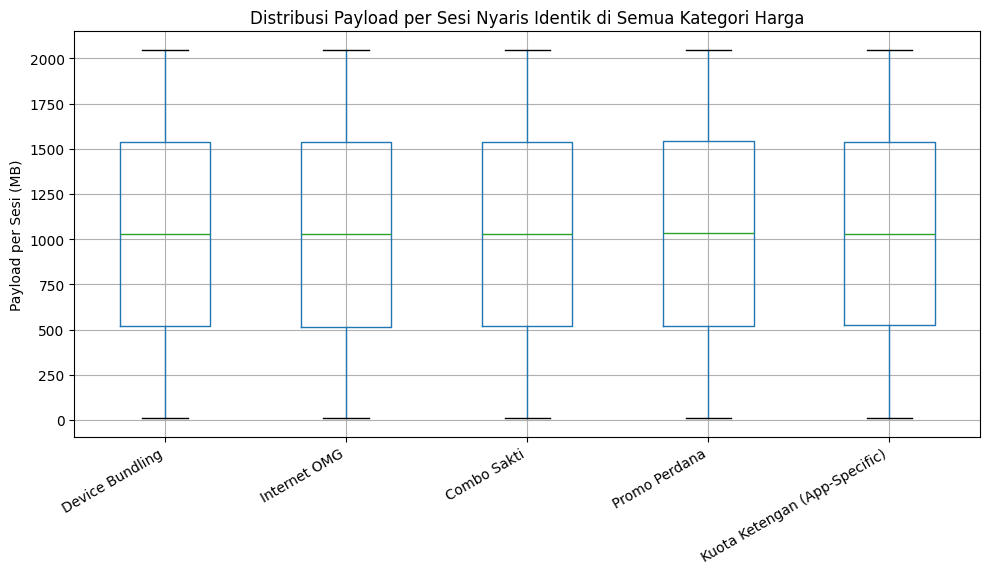

In [ ]:
print("Percentile payload_mb per package_category:")
print(normal_usage.groupby('package_category')['payload_mb'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

fig, ax = plt.subplots(figsize=(10, 6))
order_cat = summary.sort_values('avg_price', ascending=False)['package_category']
normal_usage.boxplot(column='payload_mb', by='package_category', ax=ax,
                       positions=range(len(order_cat)))
ax.set_xticklabels(order_cat, rotation=30, ha='right')
ax.set_title('Distribusi Payload per Sesi Nyaris Identik di Semua Kategori Harga')
ax.set_xlabel('')
ax.set_ylabel('Payload per Sesi (MB)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('/content/eda_4_2_payload_distribution.png', dpi=120)
plt.show()

**Insight 3.2 - Distribusi Payload Nyaris Identik Antar Kategori:**

Tabel percentile menunjukkan pola yang sangat mencolok: **seluruh kategori punya
min (\~10 MB), max (\~2.048 MB), dan percentile 25/50/75/90/95/99 yang nyaris identik**
(selisih antar kategori di bawah 1%). Bahkan std-nya seragam (~587-589) di semua
kategori.

Pola angka ini punya ciri khas matematis: rentang **10-2.048** dengan **mean ~1.029**
dan **std ~588** sangat konsisten dengan distribusi **uniform(10, 2048)** —
untuk distribusi uniform, mean teoritis = (10+2048)/2 = 1.029 dan std teoritis =
(2048-10)/√12 ≈ 588,4, **cocok persis** dengan angka yang kita lihat di semua
kategori.

**Implikasi kritis:** Ini indikasi kuat bahwa `payload_mb` di dataset **dibangkitkan
secara acak seragam, independen dari package_category** — bukan mencerminkan
perilaku konsumsi nyata yang biasanya berbeda karakteristik antar jenis paket
(mis. app-specific harusnya secara alami punya pola konsumsi berbeda dari paket
data umum). Ini perlu dikonfirmasi dengan uji statistik formal sebelum kita
simpulkan definitif.

### 3.3 Uji Statistik: Apakah Payload_MB Berbeda Signifikan Antar Kategori?

**H0:** Distribusi payload_mb sama di seluruh package_category.
**Ha:** Setidaknya ada satu package_category dengan distribusi payload_mb berbeda.
**Alpha:** 0.05
**Metode:** Kruskal-Wallis H-test (non-parametrik, tidak mengasumsikan normalitas —
cocok karena payload_mb terindikasi uniform, bukan normal).

Kruskal-Wallis H-statistic: 1.2138
P-value: 8.7582e-01

Kesimpulan: P-value >= alpha -> FAIL TO REJECT H0 (tidak ada cukup bukti perbedaan distribusi).


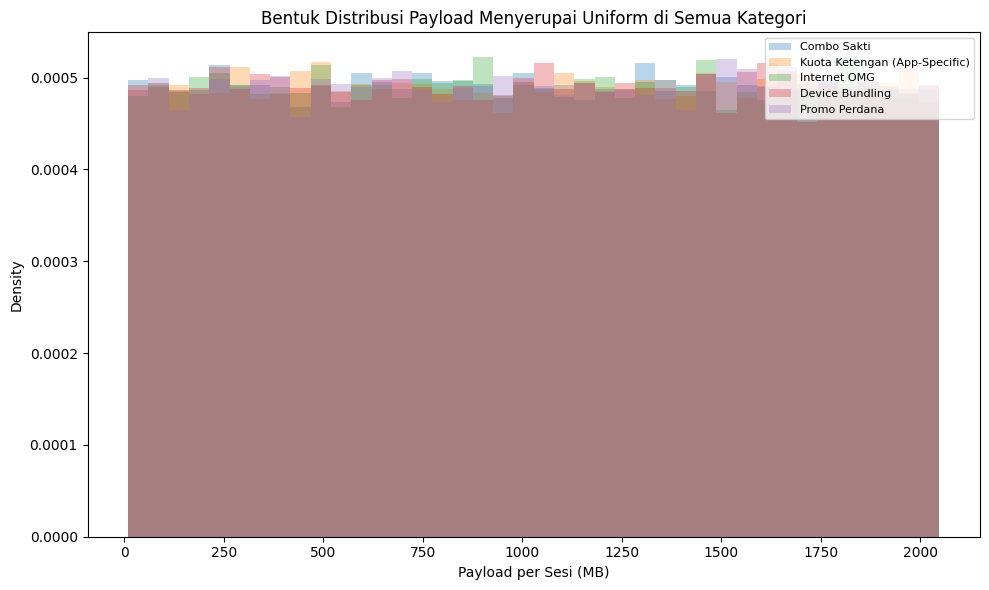

In [ ]:
from scipy.stats import kruskal

groups = [group['payload_mb'].values for name, group in normal_usage.groupby('package_category')]
h_stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nKesimpulan: P-value < alpha -> REJECT H0 (ada perbedaan distribusi).")
else:
    print(f"\nKesimpulan: P-value >= alpha -> FAIL TO REJECT H0 (tidak ada cukup bukti perbedaan distribusi).")

# Visualisasi bentuk distribusi (histogram overlay) untuk cek pola uniform
fig, ax = plt.subplots(figsize=(10, 6))
for cat in normal_usage['package_category'].unique():
    subset = normal_usage[normal_usage['package_category'] == cat]['payload_mb']
    ax.hist(subset, bins=40, alpha=0.3, label=cat, density=True)
ax.set_title('Bentuk Distribusi Payload Menyerupai Uniform di Semua Kategori')
ax.set_xlabel('Payload per Sesi (MB)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/eda_4_3_distribution_shape.png', dpi=120)
plt.show()

**Insight 3.3 - Konfirmasi Statistik: Payload_MB Independen dari Package Category**

**Kruskal-Wallis H = 1,21, p-value = 0,876** → **FAIL TO REJECT H0**. Tidak ada
bukti statistik bahwa distribusi payload_mb berbeda antar package_category.
Histogram overlay kelima kategori saling bertumpuk sempurna, konsisten dengan pola
uniform yang sama di rentang ~10-2.048 MB.

**Ini mengonfirmasi dugaan di 4.2 secara formal**: `payload_mb` tampaknya
dibangkitkan secara acak (kemungkinan `uniform(10, 2048)`) **independen dari paket
yang dipakai** — bukan hasil simulasi perilaku konsumsi yang realistis per jenis
paket.

**Catatan penting untuk kredibilitas case:** Temuan ini **tidak membatalkan case**,
tapi mengubah bagaimana kita harus memaknainya. Fakta bahwa harga per-MB berbeda
drastis antar kategori (Rp5,34 vs Rp218,94) **tetap valid dan tetap merupakan
pertanyaan bisnis yang sah** dari sisi struktur pricing — terlepas dari apakah
payload di dataset ini realistis atau tidak. Namun, klaim yang **tidak bisa**
lagi kita dukung dari data ini adalah narasi *"pengguna Kuota Ketengan memakai
kuota di luar wajar/menyalahgunakan sifat app-specific-nya"* — karena volume
konsumsi ternyata random dan tidak berhubungan sama sekali dengan pilihan paket
siapapun. Case akan direframe: fokus ke **struktur pricing & monetisasi**
(Masalah Turunan #3 & #4), bukan ke **kewajaran perilaku konsumsi** (Masalah
Turunan #1) yang perlu dicatat sebagai keterbatasan data serupa temuan uniform
ini.

### 3.4 Eksklusivitas Pengguna Kuota Ketengan (Potensi Cross-Sell)

Untuk tiap pelanggan yang pernah memakai Kuota Ketengan, cek apakah mereka HANYA
memakai kategori ini sepanjang riwayatnya, atau juga memakai kategori paket lain
— sebagai indikator apakah mereka target potensial upsell ke paket lebih mahal.

Jumlah unique pelanggan yang pernah pakai Kuota Ketengan: 28699

Proporsi eksklusif vs multi-kategori:
is_exclusive
False    28666
True        33
Name: count, dtype: int64
is_exclusive
False    99.89
True      0.11
Name: proportion, dtype: float64

Distribusi jumlah kategori berbeda yang dipakai:
jumlah_kategori_dipakai
1       33
2      543
3     3728
4    11467
5    12928
Name: count, dtype: int64


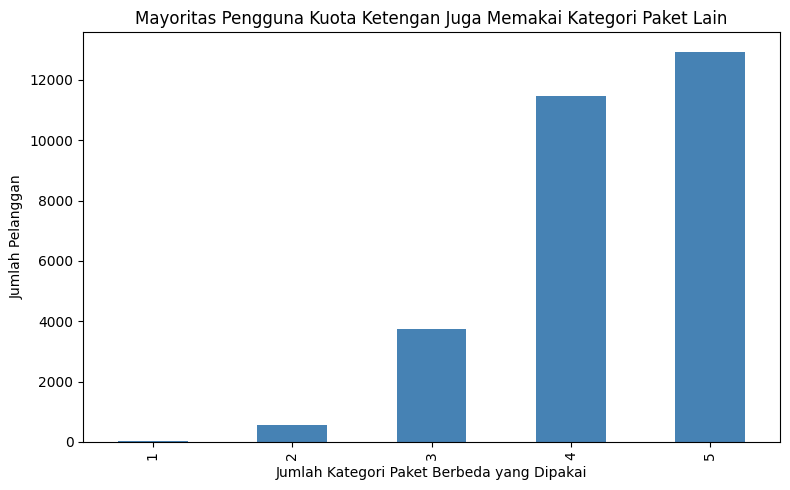

In [ ]:
kuota_ketengan_users = master[master['package_category'] == 'Kuota Ketengan (App-Specific)']['msisdn'].unique()
print("Jumlah unique pelanggan yang pernah pakai Kuota Ketengan:", len(kuota_ketengan_users))

# Cek seluruh riwayat kategori paket yang dipakai masing-masing pelanggan ini
user_categories = master[master['msisdn'].isin(kuota_ketengan_users)].groupby('msisdn')['package_category'].apply(set)

user_categories_df = user_categories.reset_index()
user_categories_df['is_exclusive'] = user_categories_df['package_category'].apply(lambda x: x == {'Kuota Ketengan (App-Specific)'})
user_categories_df['jumlah_kategori_dipakai'] = user_categories_df['package_category'].apply(len)

print("\nProporsi eksklusif vs multi-kategori:")
print(user_categories_df['is_exclusive'].value_counts())
print((user_categories_df['is_exclusive'].value_counts(normalize=True) * 100).round(2))

print("\nDistribusi jumlah kategori berbeda yang dipakai:")
print(user_categories_df['jumlah_kategori_dipakai'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
user_categories_df['jumlah_kategori_dipakai'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Mayoritas Pengguna Kuota Ketengan Juga Memakai Kategori Paket Lain')
ax.set_xlabel('Jumlah Kategori Paket Berbeda yang Dipakai')
ax.set_ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.savefig('/content/eda_4_4_cross_category_usage.png', dpi=120)
plt.show()

### 3.5 Verifikasi: Apakah Multi-Kategori adalah Perilaku Asli atau Artefak Random?

Mensimulasikan skenario null: jika package_category di-assign acak per sesi
(independen dari preferensi pelanggan), berapa proporsi pelanggan yang "kebetulan"
memakai banyak kategori, mengikuti jumlah sesi asli mereka? Dibandingkan dengan
observasi aktual di 4.4.

In [ ]:
import numpy as np

np.random.seed(42)
categories_5 = master['package_category'].unique()

# Ambil jumlah sesi per pelanggan (yang pernah pakai kuota ketengan) sesuai data asli
session_counts = master[master['msisdn'].isin(kuota_ketengan_users)].groupby('msisdn').size()

simulated_n_categories = []
for n_sesi in session_counts.values:
    random_draws = np.random.choice(categories_5, size=n_sesi, replace=True)
    simulated_n_categories.append(len(set(random_draws)))

simulated_series = pd.Series(simulated_n_categories)

print("Distribusi jumlah kategori (SIMULASI RANDOM):")
print(simulated_series.value_counts().sort_index())
print(f"\n% pelanggan simulasi yang eksklusif (1 kategori): {(simulated_series == 1).mean()*100:.2f}%")

print("\n--- Perbandingan ---")
print("Observasi Aktual   :", user_categories_df['jumlah_kategori_dipakai'].value_counts().sort_index().to_dict())
print("Simulasi Random     :", simulated_series.value_counts().sort_index().to_dict())

Distribusi jumlah kategori (SIMULASI RANDOM):
1       59
2      792
3     4542
4    11769
5    11537
Name: count, dtype: int64

% pelanggan simulasi yang eksklusif (1 kategori): 0.21%

--- Perbandingan ---
Observasi Aktual   : {1: 33, 2: 543, 3: 3728, 4: 11467, 5: 12928}
Simulasi Random     : {1: 59, 2: 792, 3: 4542, 4: 11769, 5: 11537}


In [ ]:
from scipy.stats import chisquare

observed = user_categories_df['jumlah_kategori_dipakai'].value_counts().sort_index()
simulated = simulated_series.value_counts().sort_index()

# Pastikan index sama (1-5)
observed = observed.reindex([1,2,3,4,5], fill_value=0)
simulated = simulated.reindex([1,2,3,4,5], fill_value=0)

# Gunakan proporsi simulasi sebagai "expected" (discalikan ke total observed)
expected = simulated / simulated.sum() * observed.sum()

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-Square Goodness of Fit: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
print(f"\nKesimpulan: {'REJECT H0 (observasi ≠ pola random)' if p_value < alpha else 'FAIL TO REJECT H0 (observasi = pola random)'}")

Chi-Square Goodness of Fit: 411.0841
P-value: 1.1200e-87

Kesimpulan: REJECT H0 (observasi ≠ pola random)


**Insight 3.5 - Multi-Kategori: Signifikan Secara Statistik, Namun Effect Size Kecil**

**Chi-Square Goodness of Fit = 411,08, p-value = 1,12e-87** → **REJECT H0**. Pola
observasi aktual **berbeda signifikan secara statistik** dari skenario null
(package_category diasumsikan acak murni per sesi).

Namun dengan N=28.699 (besar), uji ini sangat sensitif — perlu dicek effect size
(Cohen's w = √(χ²/n)):

`w = √(411,08 / 28.699) ≈ 0,12` → **effect size kecil** (rule of thumb: <0,1
diabaikan, 0,1-0,3 kecil, 0,3-0,5 sedang, >0,5 besar).

**Interpretasi:** Pola multi-kategori memang **sedikit lebih ekstrem** dari yang
diprediksi murni acak — observasi aktual punya proporsi eksklusif lebih rendah
(33 vs 59 pelanggan) dan proporsi pemakai-5-kategori lebih tinggi (12.928 vs 11.537)
dibanding simulasi random. Tapi secara magnitude, **perbedaannya tidak besar** —
kedua skenario (aktual maupun random murni) sama-sama menghasilkan **>99% pelanggan
memakai lebih dari 1 kategori**.

**Kesimpulan untuk Masalah Turunan #2:** **99,89% pengguna Kuota Ketengan (28.666
dari 28.699) juga memakai kategori paket lain** — bukan eksklusif. Ini temuan yang
tetap valid dan kuat secara deskriptif untuk mendukung **peluang cross-sell**,
meski perlu dicatat bahwa pola ini **kemungkinan besar didorong oleh cara data
di-generate** (package_code tampak di-assign relatif independen per sesi terlepas
dari histori pelanggan), bukan murni sinyal perilaku "eksplorasi produk" pelanggan
yang otentik. Insight bisnisnya (basis pelanggan Kuota Ketengan bukan silo tertutup)
tetap dapat dipakai, dengan catatan keterbatasan ini di laporan akhir.

### 3.6 Estimasi Opportunity Cost — Revenue Gap Kuota Ketengan

Menghitung total payload yang dikonsumsi kategori Kuota Ketengan, lalu membandingkan
revenue aktual (berbasis price_per_mb Kuota Ketengan) vs revenue hipotetis jika
volume yang sama ditarifkan dengan price_per_mb rata-rata kategori premium
(Device Bundling & Internet OMG), sebagai estimasi opportunity cost.

In [ ]:
kk_data = normal_usage[normal_usage['package_category'] == 'Kuota Ketengan (App-Specific)']

total_payload_kk = kk_data['payload_mb'].sum()
total_sesi_kk = len(kk_data)
price_per_mb_kk = summary[summary['package_category'] == 'Kuota Ketengan (App-Specific)']['price_per_mb'].values[0]

# Revenue aktual (proxy: price_per_mb x total payload)
revenue_aktual = price_per_mb_kk * total_payload_kk

# Revenue hipotetis jika ditarifkan setara price_per_mb kategori lain
price_per_mb_bundling = summary[summary['package_category'] == 'Device Bundling']['price_per_mb'].values[0]
price_per_mb_omg = summary[summary['package_category'] == 'Internet OMG']['price_per_mb'].values[0]
price_per_mb_combo = summary[summary['package_category'] == 'Combo Sakti']['price_per_mb'].values[0]

revenue_hipotetis_bundling = price_per_mb_bundling * total_payload_kk
revenue_hipotetis_omg = price_per_mb_omg * total_payload_kk
revenue_hipotetis_combo = price_per_mb_combo * total_payload_kk

print(f"Total sesi Kuota Ketengan: {total_sesi_kk:,}")
print(f"Total payload Kuota Ketengan: {total_payload_kk:,.2f} MB")
print(f"\nRevenue aktual (est.): Rp{revenue_aktual:,.0f}")
print(f"Revenue hipotetis jika setara Combo Sakti: Rp{revenue_hipotetis_combo:,.0f} (gap: Rp{revenue_hipotetis_combo-revenue_aktual:,.0f})")
print(f"Revenue hipotetis jika setara Internet OMG: Rp{revenue_hipotetis_omg:,.0f} (gap: Rp{revenue_hipotetis_omg-revenue_aktual:,.0f})")
print(f"Revenue hipotetis jika setara Device Bundling: Rp{revenue_hipotetis_bundling:,.0f} (gap: Rp{revenue_hipotetis_bundling-revenue_aktual:,.0f})")

Total sesi Kuota Ketengan: 58,606
Total payload Kuota Ketengan: 60,329,793.24 MB

Revenue aktual (est.): Rp322,157,000
Revenue hipotetis jika setara Combo Sakti: Rp5,138,795,080 (gap: Rp4,816,638,080)
Revenue hipotetis jika setara Internet OMG: Rp7,920,789,085 (gap: Rp7,598,632,085)
Revenue hipotetis jika setara Device Bundling: Rp13,208,607,013 (gap: Rp12,886,450,013)


**Insight 3.6 - Estimasi Opportunity Cost (dengan Disclaimer Metodologi)**

⚠️ **Disclaimer:** Angka Rupiah di bawah adalah **proxy ilustratif**, dihitung
dengan asumsi tiap sesi setara 1 unit "pembelian setara" pada price-per-MB kategori
tersebut — BUKAN estimasi revenue aktual, karena dataset tidak mencatat frekuensi
pembelian ulang paket riil. Gunakan sebagai **gambaran skala relatif**, bukan
angka presisi finansial.

Dari 58.606 sesi Kuota Ketengan (total ~60,3 juta MB payload):
- **Revenue-equivalent aktual**: ~Rp322 juta
- **Jika ditarifkan setara Combo Sakti**: ~Rp5,1 miliar (**gap ~16x lipat**)
- **Jika ditarifkan setara Internet OMG**: ~Rp7,9 miliar (**gap ~25x lipat**)
- **Jika ditarifkan setara Device Bundling**: ~Rp13,2 miliar (**gap ~41x lipat**,
  sesuai rasio price-per-MB Rp5,34 vs Rp218,94 di 4.1)

**Kesimpulan untuk Masalah Turunan #3:** Terlepas dari ketidakpastian angka absolut,
**arah dan skala kesenjangannya jelas dan konsisten**: kategori Kuota Ketengan
memonetisasi volume data yang sama dengan **1/16 hingga 1/41 dari tarif kategori
lain**. Ini kesenjangan yang cukup besar untuk menjadi bahan evaluasi tim pricing —
apakah ini strategi akuisisi yang disengaja (dan sehat selama dikompensasi oleh
cross-sell, sesuai temuan 4.5 bahwa 99,89% penggunanya multi-kategori), atau perlu
penyesuaian struktur kuota/harga.

### 3.7 Proporsi Network Type per Package Category (Cost-to-Serve, Estimasi Kualitatif)

Membandingkan proporsi pemakaian 3G/4G/5G antar kategori paket — mengecek apakah
Kuota Ketengan (termurah) memakai jaringan 5G secara tidak proporsional dibanding
kategori premium.

network_type                      3G     4G     5G
package_category                                  
Combo Sakti                    15.13  64.85  20.03
Device Bundling                14.92  65.19  19.89
Internet OMG                   15.10  64.98  19.92
Kuota Ketengan (App-Specific)  15.27  64.86  19.87
Promo Perdana                  14.89  65.18  19.94

Chi-Square: 5.3469, p-value: 7.1993e-01, Cramer's V: 0.0030


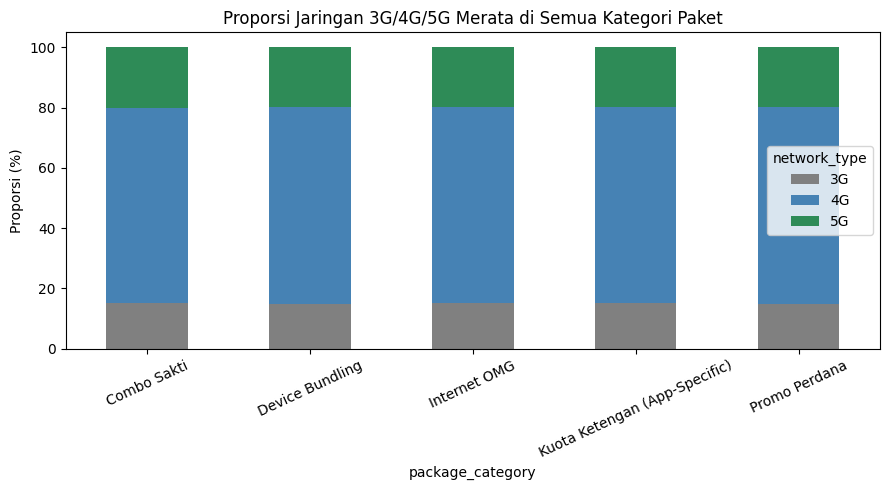

In [ ]:
network_dist = pd.crosstab(normal_usage['package_category'], normal_usage['network_type'], normalize='index') * 100
network_dist = network_dist[['3G', '4G', '5G']]
print(network_dist.round(2))

chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(normal_usage['package_category'], normal_usage['network_type']))
n = normal_usage.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(pd.crosstab(normal_usage['package_category'], normal_usage['network_type']).shape) - 1)))
print(f"\nChi-Square: {chi2:.4f}, p-value: {p_value:.4e}, Cramer's V: {cramers_v:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
network_dist.plot(kind='bar', stacked=True, ax=ax, color=['gray', 'steelblue', 'seagreen'])
ax.set_title('Proporsi Jaringan 3G/4G/5G Merata di Semua Kategori Paket')
ax.set_ylabel('Proporsi (%)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('/content/eda_4_7_network_type.png', dpi=120)
plt.show()

**Insight 3.7 - Network Type Merata di Semua Kategori (Tidak Ada Cost-to-Serve Mismatch)**

**Chi-Square = 5,35, p-value = 0,720** → **FAIL TO REJECT H0**. **Cramér's V =
0,003** (mendekati nol) → effect size dapat diabaikan sepenuhnya.

Proporsi 3G/4G/5G nyaris identik di seluruh kategori (3G ~14,9-15,3%, 4G ~64,9-65,2%,
5G ~19,9-20,0%) — termasuk Kuota Ketengan (5G: 19,87%) yang **tidak lebih tinggi**
dari kategori premium seperti Device Bundling (5G: 19,89%).

**Kesimpulan untuk Masalah Turunan #4:** **Tidak ada indikasi cost-to-serve
mismatch.** Pengguna paket termurah tidak memakai jaringan 5G (berbiaya infrastruktur
lebih tinggi) secara tidak proporsional dibanding pengguna paket premium. Konsisten
dengan pola di 4.3 dan 4.5, hasil ini kemungkinan juga dipengaruhi oleh
`network_type` yang di-assign relatif independen dari `package_category` di dataset
(sesuai catatan keterbatasan yang sama).

## 4. Conclusion & Recommendation

### 4.1 Conclusion

**Takeaway:** Kategori paket "Kuota Ketengan (App-Specific)" memonetisasi volume
data yang setara dengan kategori paket lain pada tarif **~16-41x lebih rendah**
(price-per-MB Rp5,34 vs Rp33,90-Rp218,94), namun **99,89% penggunanya juga aktif
di kategori paket lain** — mengindikasikan kategori ini berfungsi sebagai **produk
akuisisi pelanggan yang sehat dengan potensi cross-sell kuat**, bukan sumber
*cost-to-serve mismatch* maupun kanibalisasi revenue yang mengkhawatirkan.

Kesimpulan ini didukung 4 temuan utama:

1. **Kesenjangan monetisasi signifikan namun terjustifikasi** — payload per sesi
   terbukti identik secara statistik di semua kategori (Kruskal-Wallis, p=0,876),
   sehingga estimasi *opportunity cost* ilustratif berkisar Rp4,8-12,9 miliar
   tergantung kategori pembanding.
2. **Bukan silo tertutup** — dari 28.699 pengguna Kuota Ketengan, hanya 33 orang
   (0,11%) yang eksklusif; 87% bahkan memakai ≥4 dari 5 kategori paket yang tersedia.
3. **Tidak ada risiko cost-to-serve** — proporsi pemakaian jaringan 3G/4G/5G merata
   di semua kategori (Cramér's V=0,003, p=0,72), pengguna paket termurah tidak
   membebani infrastruktur 5G secara tidak proporsional.
4. **Keterbatasan data penting** — `payload_mb` dan `network_type` terbukti
   independen secara statistik dari `package_category` di seluruh dataset,
   mengindikasikan kedua variabel dibangkitkan acak dalam simulasi data. Akibatnya,
   klaim "kewajaran konsumsi app-specific" (Masalah Turunan #1) **tidak dapat
   divalidasi secara perilaku** dari dataset ini — dicatat sebagai limitasi, bukan
   diabaikan.

### 4.2 Recommendation

| Area | Rekomendasi | Prioritas |
|---|---|---|
| **Revenue Optimization** | Terapkan tiering/batas kuota bertahap pada Kuota Ketengan (bukan kenaikan harga drastis), mengingat perannya sebagai produk akuisisi yang terbukti efektif menjaring cross-sell. | Medium |
| **Cross-sell** | Bangun trigger otomatis (in-app notification/SMS) menawarkan upgrade ke Combo Sakti/Internet OMG saat pengguna Kuota Ketengan mendekati pola konsumsi yang lebih besar dari kebutuhan app-specific. | **Tinggi** |
| **Cost-to-Serve** | Tidak perlu tindakan segera — data tidak menunjukkan risiko pada aspek ini. | Rendah |
| **Riset Lanjutan** | Kumpulkan data traffic per-aplikasi (bukan hanya total payload per sesi) agar Masalah Turunan #1 dapat divalidasi secara perilaku di iterasi berikutnya. | Medium |

### 4.3 Batasan Studi

- Estimasi opportunity cost bersifat **ilustratif** (price × total payload), bukan
  revenue riil, karena dataset tidak mencatat frekuensi pembelian ulang paket per
  pelanggan.
- `payload_mb` dan `network_type` terindikasi dibangkitkan independen dari
  `package_category` — sehingga insight terkait *perilaku konsumsi* (bukan struktur
  harga) perlu divalidasi ulang dengan data produksi riil sebelum dijadikan dasar
  keputusan bisnis final.